In [1]:
import platform
import matplotlib.pyplot as plt

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumBarunGothic')

plt.rc('axes', unicode_minus=False)

In [2]:
import pandas as pd

data = {
    'date': pd.date_range(start='2024-01-01', periods=5),
    'age': [25, 30,None, 22, 28],
    'gender': ['M', None, 'F', 'F','M'],
    'bmi': [23.5, 27.8, 30.2, None, 24.1],
    'temperature': [22.5, None, 23.0, None, 21.8]
}
df = pd.DataFrame(data)
print(df)


        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5 non-null      datetime64[us]
 1   age          4 non-null      float64       
 2   gender       4 non-null      str           
 3   bmi          4 non-null      float64       
 4   temperature  3 non-null      float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 332.0 bytes


In [4]:
#print(df.isnull())
print(df.isnull().sum())

print(df.isnull().mean())

print(df.notnull())

date           0
age            1
gender         1
bmi            1
temperature    2
dtype: int64
date           0.0
age            0.2
gender         0.2
bmi            0.2
temperature    0.4
dtype: float64
   date    age  gender    bmi  temperature
0  True   True    True   True         True
1  True   True   False   True        False
2  True  False    True   True         True
3  True   True    True  False        False
4  True   True    True   True         True


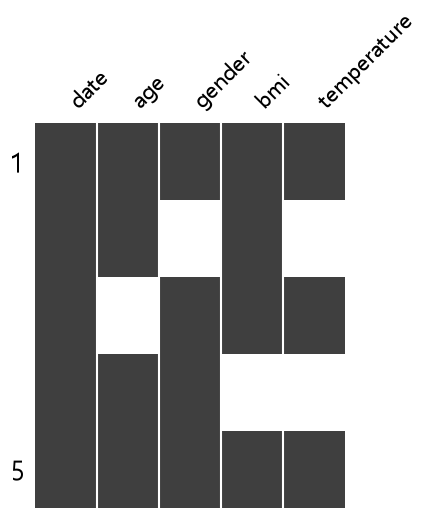

In [5]:
import missingno as msno

msno.matrix(df, figsize=(4, 5), sparkline=False)
plt.show()

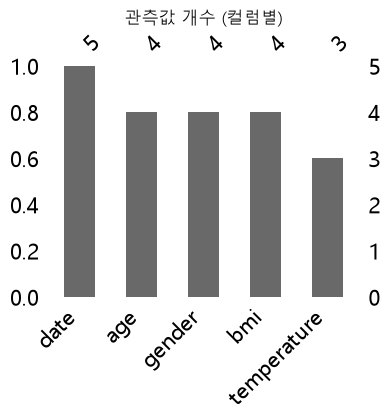

In [6]:
msno.bar(df, figsize=(4, 3))
plt.title("관측값 개수 (컬럼별)")
plt.show()

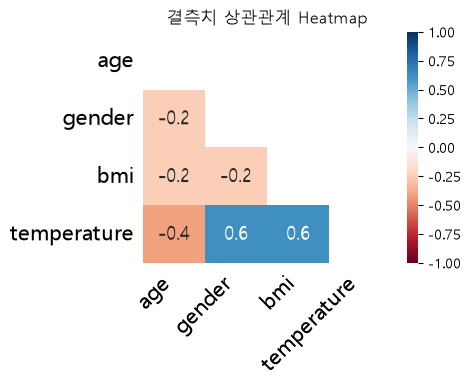

In [7]:
msno.heatmap(df, figsize=(4, 3))
plt.title("결측치 상관관계 Heatmap")
plt.show()

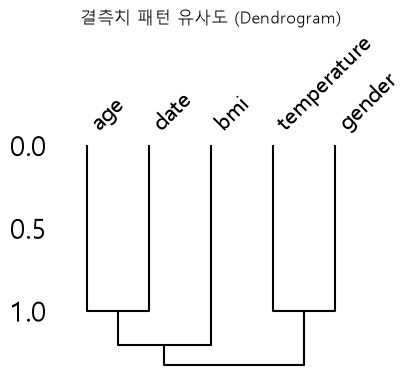

In [8]:
msno.dendrogram(df, figsize=(4, 3))
plt.title("결측치 패턴 유사도 (Dendrogram)")
plt.show()

In [9]:
df_1 = df.copy()
print(df_1)

df_1['age'] = df_1['age'].fillna(df_1['age'].mean())
df_1['bmi'] = df_1['bmi'].fillna(df_1['bmi'].median())
df_1['temperature'] = df_1['temperature'].fillna(df_1['temperature'].median())

df_1['gender'] = df_1['gender'].fillna(df_1['gender'].mode()[0])
df_1

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8


,date,age,gender,bmi,temperature
0,2024-01-01,25.00,M,23.50,22.5
1,2024-01-02,30.00,F,27.80,22.5
2,2024-01-03,26.25,F,30.20,23.0
3,2024-01-04,22.00,F,25.95,22.5
4,2024-01-05,28.00,M,24.10,21.8


In [10]:
df_2 = df.copy()
print(df_2)

df_ffill = df_2.ffill()
print("\nForard Fill 처리:")
print(df_ffill)

df_3 = df.copy()
df_bfill = df_3.bfill()
print("\nBackward Fill 처리:")
print(df_bfill)

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8

Forard Fill 처리:
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0      M  27.8         22.5
2 2024-01-03  30.0      F  30.2         23.0
3 2024-01-04  22.0      F  30.2         23.0
4 2024-01-05  28.0      M  24.1         21.8

Backward Fill 처리:
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0      F  27.8         23.0
2 2024-01-03  22.0      F  30.2         23.0
3 2024-01-04  22.0      F  24.1         21.8
4 2024-01-05  28.0      M  24.1         21.8


In [11]:
from sklearn.impute import KNNImputer

df_4 = df.copy()
print(df_4.info())
print(df)

numeric_df = df_4[['age', 'bmi']]

imputer = KNNImputer(n_neighbors=2)
df_knn = pd.DataFrame(imputer.fit_transform(numeric_df), columns=numeric_df.columns)
print(df_knn)

df_4[['age', 'bmi']] = df_knn
df_4

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5 non-null      datetime64[us]
 1   age          4 non-null      float64       
 2   gender       4 non-null      str           
 3   bmi          4 non-null      float64       
 4   temperature  3 non-null      float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 332.0 bytes
None
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
    age   bmi
0  25.0  23.5
1  30.0  27.8
2  29.0  30.2
3  22.0  23.8
4  28.0  24.1


,date,age,gender,bmi,temperature
0,2024-01-01,25.0,M,23.5,22.5
1,2024-01-02,30.0,NaN,27.8,NaN
2,2024-01-03,29.0,F,30.2,23.0
3,2024-01-04,22.0,F,23.8,NaN
4,2024-01-05,28.0,M,24.1,21.8


In [12]:
import numpy as np

df_5 = df.copy()
print(df_5)

numeric_cols = df_5.select_dtypes(include=[np.number])

df_linear = numeric_cols.interpolate(method='linear')
df_linear

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8


,age,bmi,temperature
0,25.0,23.50,22.50
1,30.0,27.80,22.75
2,26.0,30.20,23.00
3,22.0,27.15,22.40
4,28.0,24.10,21.80


In [13]:
df_6 = df.copy()
print(df_6)

df_6 = df_6.set_index('date')

numeric_cols = df_6.select_dtypes(include=[np.number])
df_time = numeric_cols.interpolate(method='time')
df_time

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8


,age,bmi,temperature
date,,,
2024-01-01,25.0,23.50,22.50
2024-01-02,30.0,27.80,22.75
2024-01-03,26.0,30.20,23.00
2024-01-04,22.0,27.15,22.40
2024-01-05,28.0,24.10,21.80


In [14]:
df_7 = df.copy()
print(df_7)

df_drop_rows = df_7.dropna()
print(df_drop_rows)
print(df_7)

df_7.dropna(inplace=True)
print(df_7)

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
4 2024-01-05  28.0      M  24.1         21.8
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
4 2024-01-05  28.0      M  24.1         21.8


In [15]:
df_8 = df.copy()
print(df_8)

df_drop_column = df_8.drop(columns=['gender'])
print(df_drop_column)
print(df_8)

df_8.drop(columns=['gender'],inplace=True)
print(df_8)

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
        date   age   bmi  temperature
0 2024-01-01  25.0  23.5         22.5
1 2024-01-02  30.0  27.8          NaN
2 2024-01-03   NaN  30.2         23.0
3 2024-01-04  22.0   NaN          NaN
4 2024-01-05  28.0  24.1         21.8
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
        date   age   bmi  temperature
0 2024-01-01  25.0  23.5         22.5
1 2024-01-02  30.0  27.8          NaN
2 2024-01-03   NaN  30.2         23.0
3 2024-01-04  22.0   NaN          NaN
4 2024-01-05  28.0  24.1         21.8


In [16]:
data = {
    'Name': ['Alice',  'Bob', 'Alice','David',  'Eve','Bob'],
    'Age': [25, 30, 25, 35, 40, 30],
    'City': ['Seoul','Busan','Seoul','Incheon', 'Seoul',  'Busan']
}

df = pd.DataFrame(data)
print("원본 데이터:\n:", df)

print("중복 여부 (전체 행 기준):")
print(df.duplicated())

df_no_duplicates = df.drop_duplicates()
print("중복제거 결과(전체 열 기준):\n",df_no_duplicates)
print(df)

df_name_unique = df.drop_duplicates(subset=['Name'])
print("\n이름 기준 중복 제거(첫번째만 남김):\n", df_name_unique)

df_name_last = df.drop_duplicates(subset=['Name'], keep='last')
print("\n이름 기준중복 제거(첫번째만 남김):\n", df_name_last)

df_duplicates_only = df[df.duplicated()]
print("\n중복된 행만 추출:\n", df_duplicates_only)

원본 데이터:
:     Name  Age     City
0  Alice   25    Seoul
1    Bob   30    Busan
2  Alice   25    Seoul
3  David   35  Incheon
4    Eve   40    Seoul
5    Bob   30    Busan
중복 여부 (전체 행 기준):
0    False
1    False
2     True
3    False
4    False
5     True
dtype: bool
중복제거 결과(전체 열 기준):
     Name  Age     City
0  Alice   25    Seoul
1    Bob   30    Busan
3  David   35  Incheon
4    Eve   40    Seoul
    Name  Age     City
0  Alice   25    Seoul
1    Bob   30    Busan
2  Alice   25    Seoul
3  David   35  Incheon
4    Eve   40    Seoul
5    Bob   30    Busan

이름 기준 중복 제거(첫번째만 남김):
     Name  Age     City
0  Alice   25    Seoul
1    Bob   30    Busan
3  David   35  Incheon
4    Eve   40    Seoul

이름 기준중복 제거(첫번째만 남김):
     Name  Age     City
2  Alice   25    Seoul
3  David   35  Incheon
4    Eve   40    Seoul
5    Bob   30    Busan

중복된 행만 추출:
     Name  Age   City
2  Alice   25  Seoul
5    Bob   30  Busan


In [18]:
import pandas as pd

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Distance_km': [5.2, 8.5, 3.1, 12.0],
    'Time_min': [15,25,10, 40]
}

df = pd.DataFrame(data)
print("원본 데이터:\n", df)

df['Distance_m'] = df['Distance_km'] * 1000
df['Time_hr'] = df['Time_min'] / 60

print(df)




원본 데이터:
       Name  Distance_km  Time_min
0    Alice          5.2        15
1      Bob          8.5        25
2  Charlie          3.1        10
3    David         12.0        40
      Name  Distance_km  Time_min  Distance_m   Time_hr
0    Alice          5.2        15      5200.0  0.250000
1      Bob          8.5        25      8500.0  0.416667
2  Charlie          3.1        10      3100.0  0.166667
3    David         12.0        40     12000.0  0.666667


In [19]:
import pandas as pd

data = {
    'Age': ['25', '30', '40'],
    'Salary': [50000.0, 60000.0, 70000.0],
    'JoinDate': ['2023-01-01', '2023-02-15', '2023-03-10'],
    'Gender': ['Male', 'Female', 'Male']
}

df = pd.DataFrame(data)
print("기존 자료형:\n", df.dtypes)

df['Age'] = df['Age'].astype(int)

df['JoinDate'] = pd.to_datetime(df['JoinDate'])

df['Gender'] = df['Gender'].astype('category')

print("변환 후 자료형:\n", df.dtypes)
print(df)


기존 자료형:
 Age             str
Salary      float64
JoinDate        str
Gender          str
dtype: object
변환 후 자료형:
 Age                  int64
Salary             float64
JoinDate    datetime64[us]
Gender            category
dtype: object
   Age   Salary   JoinDate  Gender
0   25  50000.0 2023-01-01    Male
1   30  60000.0 2023-02-15  Female
2   40  70000.0 2023-03-10    Male


### 구간분할 ###

In [20]:
# 고정 구간
import pandas as pd
import numpy as np

data = pd.DataFrame({
    'age': [18, 25, 32, 40, 52, 60, 70, 85]
})

data['age_bin'], bin_dividers=pd.cut(data['age'], bins=4,labels=False, retbins=True)
print(bin_dividers)
print(data)


[17.933 34.75  51.5   68.25  85.   ]
   age  age_bin
0   18        0
1   25        0
2   32        0
3   40        1
4   52        2
5   60        2
6   70        3
7   85        3


In [22]:
# 동등 분포 구간

data['age_qbin'], bin_dividers=pd.qcut(data['age'], q=4, labels=False, retbins=True)
print(bin_dividers)
print(data)

[18.   30.25 46.   62.5  85.  ]
   age  age_bin  age_qbin
0   18        0         0
1   25        0         0
2   32        0         1
3   40        1         1
4   52        2         2
5   60        2         2
6   70        3         3
7   85        3         3


In [24]:
# 사용자 정의 구간 지정

bins = [0, 30, 50, 70, 100]
labels = ['청년', '중년', '장년', '노년']

data['age_group'], bin_dividers=pd.cut(data['age'], bins=bins, labels=labels, right=False, retbins=True)
print(bin_dividers)
print(data)

[  0  30  50  70 100]
   age  age_bin  age_qbin age_group
0   18        0         0        청년
1   25        0         0        청년
2   32        0         1        중년
3   40        1         1        중년
4   52        2         2        장년
5   60        2         2        장년
6   70        3         3        노년
7   85        3         3        노년


### 더미변수 ###

In [26]:
import pandas as pd

df = pd.DataFrame({'age': [18, 25, 32, 40,52, 60, 70,85]})

df['age_bin'], bin_dividers=pd.cut(df['age'], bins=[0, 30, 50, 70, 100], labels=['청년', '중년', '장년', '노년'], retbins=True)
print(bin_dividers)
print(df)

age_dummies = pd.get_dummies(df['age_bin'], prefix='age')

df = pd.concat([df, age_dummies],axis=1)

print(df)


[  0  30  50  70 100]
   age age_bin
0   18      청년
1   25      청년
2   32      중년
3   40      중년
4   52      장년
5   60      장년
6   70      장년
7   85      노년
   age age_bin  age_청년  age_중년  age_장년  age_노년
0   18      청년    True   False   False   False
1   25      청년    True   False   False   False
2   32      중년   False    True   False   False
3   40      중년   False    True   False   False
4   52      장년   False   False    True   False
5   60      장년   False   False    True   False
6   70      장년   False   False    True   False
7   85      노년   False   False   False    True


In [29]:
from sklearn.preprocessing import KBinsDiscretizer
import pandas as pd
import numpy as np

X = np.array([[18], [25], [32], [40], [52], [60], [70], [85]])

kbd = KBinsDiscretizer(n_bins=4, encode='onehot-dense', strategy='uniform')
X_binned = kbd.fit_transform(X)

df = pd.DataFrame(X_binned, columns=[f'bin_{i}' for i in range(X_binned.shape[1])])
df['age'] = X.flatten()

print(df)

   bin_0  bin_1  bin_2  bin_3  age
0    1.0    0.0    0.0    0.0   18
1    1.0    0.0    0.0    0.0   25
2    1.0    0.0    0.0    0.0   32
3    0.0    1.0    0.0    0.0   40
4    0.0    0.0    1.0    0.0   52
5    0.0    0.0    1.0    0.0   60
6    0.0    0.0    0.0    1.0   70
7    0.0    0.0    0.0    1.0   85


In [31]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(["red", "blue", "green"])
y

array([2, 0, 1])

In [32]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
X = encoder.fit_transform([["red"], ["blue"], ["green"]])
X

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [34]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
X = encoder.fit_transform([["low"], ["medium"], ["high"]])
X

array([[1.],
       [2.],
       [0.]])

## data12_데이터프레임의 다양한 응용 ##

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'name': ['Alice', 'Bob', 'John'],
    'score': [88, 92, 95],
    'point': [3, 5, 4],
    'gender': ['F', 'M', 'M']
})

def add_bonus(n):
    return n + 5

def add_bonus2(n, m):
    return n+m

def add_plus(n):
    return n+1

df['bonus'] = df['score'].map(add_bonus)

df['bonus2'] = df['score'].apply(add_bonus2, m=5)

df['bonus3'] = df['score'].apply(lambda n, m : n+m, m=5)

df[['score_2', 'plus']] = df[['score', 'point']].apply(add_plus)

df['name_length'] = df['name'].map(len)

df['score_sqrt'] = df['score'].apply(np.sqrt)

df_upper = df[['name']].map(str.upper)

df['gender_num'] = df['gender'].replace({'F':0, 'M':1})

df['gender_num'] = df['gender_num'].astype('int')

def add_bonus(df):
    df['bonus4'] = df['score'] + 5
    return df

df = df.pipe(add_bonus)
print(df)



    name  score  point gender  bonus  bonus2  bonus3  score_2  plus  \
0  Alice     88      3      F     93      93      93       89     4   
1    Bob     92      5      M     97      97      97       93     6   
2   John     95      4      M    100     100     100       96     5   

   name_length  score_sqrt  gender_num  bonus4  
0            5    9.380832           0      93  
1            3    9.591663           1      97  
2            4    9.746794           1     100  
